## Подготовка

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('data/r5_eda.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   int64  
 6   total_sulfur_dioxide  6497 non-null   int64  
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(9), int64(3)
memory usage: 609.2 KB


In [5]:
y = data['quality']
X = data.drop('quality', axis=1)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((5197, 11), (5197,), (1300, 11), (1300,))

In [9]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

## Реализация пользовательских функций

In [10]:
import numpy as np

$ MAE=\frac{1}{m}{\sum_{i=1}^{m}|y_i-\hat{y}_i|} $

In [11]:
def mae_metrick(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

$ MSE=\frac{1}{m}{\sum_{i=1}^{m}(y_i-\hat{y}_i)^2} $

In [12]:
def mse_metrick(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

$ RMSE=\sqrt{\frac{1}{m}{\sum_{i=1}^{m}(y_i-\hat{y}_i)^2}} $

In [13]:
def rmse_metrick(y_true, y_pred):
    return np.sqrt(mse_metrick(y_true, y_pred))

$ MAPE=\frac{1}{m}\sum_{i=1}^{m}{|\frac{y_i-\hat{y}_i}{y_i}|} $

In [14]:
def mape_metrick(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))

$ R^2=\frac{MSE}{\frac{1}{m}{\sum_{i=1}^{m}(y_i-\bar{y})^2}} $. $\bar{y}$ - среднее значение целевого признака.

In [15]:
def r2_score_metrick(y_true, y_pred):
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    numerator = mse_metrick(y_true, y_pred)
    return numerator / denominator

Вспомогательные

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from math import sqrt

In [17]:
def sklearn_metrick_printer(y_true, y_pred):
    print(f'MAE: {mean_absolute_error(y_true, y_pred)}')
    print(f'MSE: {mean_squared_error(y_true, y_pred)}')
    print(f'RMSE: {sqrt(mean_squared_error(y_true, y_pred))}')
    print(f'MAPE: {mean_absolute_percentage_error(y_true, y_pred)}')
    print(f'R^2: {r2_score(y_true, y_pred)}')

In [18]:
def metrick_printer(y_true, y_pred):
    print(f'MAE: {mae_metrick(y_true, y_pred)}')
    print(f'MSE: {mse_metrick(y_true, y_pred)}')
    print(f'RMSE: {rmse_metrick(y_true, y_pred)}')
    print(f'MAPE: {mape_metrick(y_true, y_pred)}')
    print(f'R^2: {r2_score_metrick(y_true, y_pred)}')

In [19]:
def return_metricks(y_true, y_pred):
    return [mean_absolute_error(y_true, y_pred), mean_squared_error(y_true, y_pred), sqrt(mean_squared_error(
        y_true, y_pred)), mean_absolute_percentage_error(y_true, y_pred), r2_score(y_true, y_pred)]

## Простая линейная регрессия

In [20]:
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)

### Метрики

In [21]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5659441306326719
MSE: 0.5393816860286575
RMSE: 0.7344260929655602
MAPE: 0.0995017903272174
R^2: 0.29358503173566


In [22]:
metrick_printer(y_test, y_pred)

MAE: 0.5659441306326719
MSE: 0.5393816860286575
RMSE: 0.7344260929655602
MAPE: 0.0995017903272174
R^2: 0.0005433961294341078


In [23]:
len(lr.coef_)
lr.coef_

array([ 5.89067650e-02, -1.34659358e+00, -8.09661500e-02,  4.51708557e-02,
       -2.49428865e-01,  5.69070066e-03, -2.52517388e-03, -5.58675091e+01,
        4.55951756e-01,  8.04232059e-01,  2.64384499e-01])

## Линейная регрессия с L1-регуляризацией

In [351]:
lasso = Lasso(alpha=0.5).fit(X_train, y_train)
y_pred = lasso.predict(X_test)

### Метрики

In [352]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.6813482018221625
MSE: 0.7567484945204498
RMSE: 0.8699129235276654
MAPE: 0.1231195527991468
R^2: 0.011264264296132476


In [353]:
metrick_printer(y_test, y_pred)

MAE: 0.6813482018221625
MSE: 0.7567484945204498
RMSE: 0.8699129235276654
MAPE: 0.1231195527991468
R^2: 0.0007605659505414366


In [354]:
lasso.coef_

array([-0.        , -0.        ,  0.        , -0.        , -0.        ,
        0.00496933, -0.00160236, -0.        ,  0.        ,  0.        ,
        0.        ])

### Подбор гиперпараметров

In [355]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
import numpy as np
import optuna

GridSearchCV

In [356]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10]}

In [357]:
grid = GridSearchCV(Lasso(), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10]},
             scoring='r2')

In [358]:
print("Best alpha:", grid.best_params_['alpha'])
print("Best R^2:", grid.best_score_)

Best alpha: 0.001
Best R^2: 0.2819612269236712


RandomizedSearchCV

In [359]:
param_dist = {'alpha': np.logspace(-4, 1, 100)}

In [360]:
random_search = RandomizedSearchCV(
    Lasso(), param_dist, n_iter=20, cv=5, scoring='r2', random_state=42)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=Lasso(), n_iter=20,
                   param_distributions={'alpha': array([1.00000000e-04, 1.12332403e-04, 1.26185688e-04, 1.41747416e-04,
       1.59228279e-04, 1.78864953e-04, 2.00923300e-04, 2.25701972e-04,
       2.53536449e-04, 2.84803587e-04, 3.19926714e-04, 3.59381366e-04,
       4.03701726e-04, 4.53487851e-04, 5.09413801e-04, 5.72236766e-04,
       6.42807312e-04, 7.22080...
       6.89261210e-01, 7.74263683e-01, 8.69749003e-01, 9.77009957e-01,
       1.09749877e+00, 1.23284674e+00, 1.38488637e+00, 1.55567614e+00,
       1.74752840e+00, 1.96304065e+00, 2.20513074e+00, 2.47707636e+00,
       2.78255940e+00, 3.12571585e+00, 3.51119173e+00, 3.94420606e+00,
       4.43062146e+00, 4.97702356e+00, 5.59081018e+00, 6.28029144e+00,
       7.05480231e+00, 7.92482898e+00, 8.90215085e+00, 1.00000000e+01])},
                   random_state=42, scoring='r2')

In [361]:
print("Best alpha:", random_search.best_params_['alpha'])
print("Best R^2:", random_search.best_score_)

Best alpha: 0.00015922827933410923
Best R^2: 0.2826625530518152


Фреймворк Optuna

In [362]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
    model = Lasso(alpha=alpha)
    score = cross_val_score(model, X_train, y_train, scoring='r2', cv=5).mean()
    return score

In [363]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2025-06-01 20:24:56,141] A new study created in memory with name: no-name-dbd91f55-ace5-4580-8734-8c0055a10e5f
C:\Users\andre\AppData\Local\Temp\ipykernel_16176\1532896469.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
[I 2025-06-01 20:24:56,158] Trial 0 finished with value: 0.2735821660356165 and parameters: {'alpha': 0.007551560730015521}. Best is trial 0 with value: 0.2735821660356165.
C:\Users\andre\AppData\Local\Temp\ipykernel_16176\1532896469.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
[I 2025-06-01 20:24:56,172] Trial 1 finished with value: 

In [364]:
print("Best alpha:", study.best_params['alpha'])
print("Best R^2:", study.best_value)

Best alpha: 0.00014579329600014477
Best R^2: 0.28266296069481955


Сравнение гиперпараметров

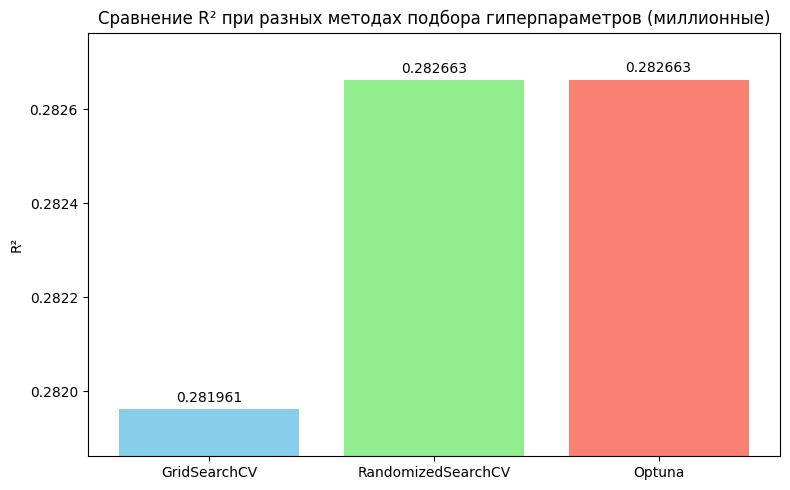

In [365]:
models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores, color=[
              'skyblue', 'lightgreen', 'salmon'])

ax.set_ylabel('R²')
ax.set_title(
    'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

margin = 0.0001
y_min = min(r2_scores) - margin
y_max = max(r2_scores) + margin

ax.set_ylim(y_min, y_max)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.6f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Обучение с наилучшим гиперпараметром

In [366]:
lasso_best = Lasso(alpha=0.0001).fit(X_train, y_train)
y_pred_new = lasso_best.predict(X_test)

### Метрики с наилучшим гиперпараметром

In [367]:
sklearn_metrick_printer(y_test, y_pred_new)

MAE: 0.5704604626833141
MSE: 0.5396883590096313
RMSE: 0.7346348473967399
MAPE: 0.1023769338167861
R^2: 0.29486590252901923


In [368]:
lasso_best.coef_

array([ 0.00986311, -1.4451218 , -0.05021159,  0.02296515, -0.69661148,
        0.00664656, -0.00248036, -0.        ,  0.1843961 ,  0.54772919,
        0.3225278 ])

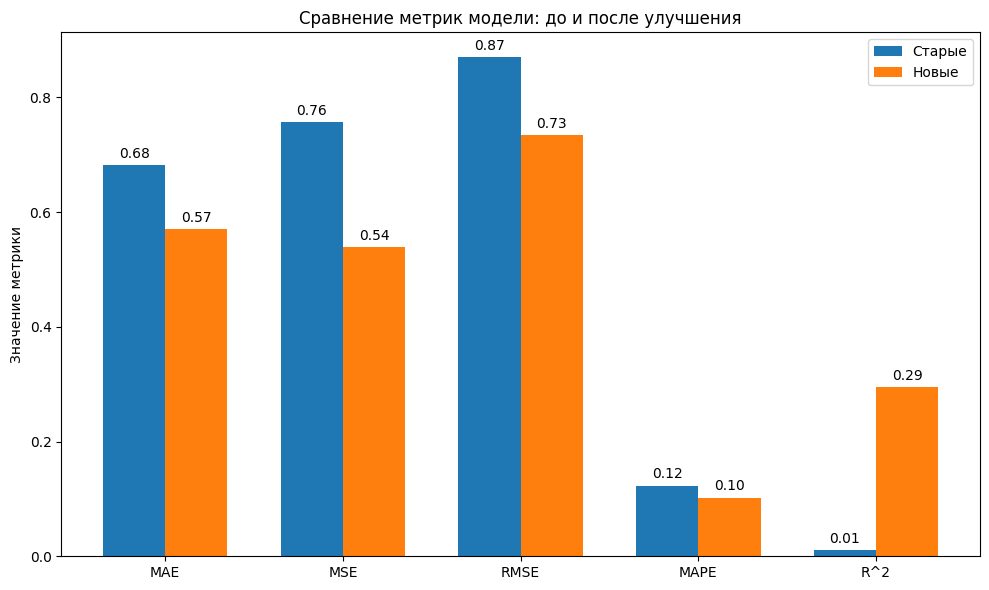

In [369]:
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R^2']

old_values = return_metricks(y_test, y_pred)

new_values = return_metricks(y_test, y_pred_new)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Старые')
bars2 = ax.bar(x + width/2, new_values, width, label='Новые')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик модели: до и после улучшения')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_16176\2118410706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\andre\AppData\Local\Temp\ipykernel_16176\2118410706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns

<Axes: xlabel='quality', ylabel='Density'>

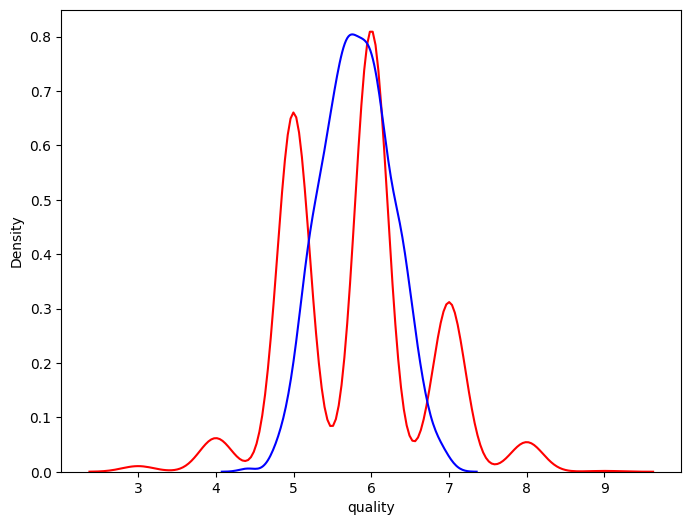

In [370]:
plt.figure(figsize=(8, 6))

ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred_new, hist=False, color='Blue',
             ax=ax1, label='Predicted weight')

## Линейная регрессия с L2-регуляризацией

In [371]:
ridge = Ridge(alpha=0.5).fit(X_train, y_train)
y_pred = ridge.predict(X_test)

### Метрики

In [372]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5703755341870164
MSE: 0.5395800321374192
RMSE: 0.7345611153181328
MAPE: 0.10236441273409284
R^2: 0.29500743786139016


In [373]:
metrick_printer(y_test, y_pred)

MAE: 0.5703755341870164
MSE: 0.5395800321374192
RMSE: 0.7345611153181328
MAPE: 0.10236441273409284
R^2: 0.0005423019708758538


In [374]:
len(ridge.coef_)
ridge.coef_

array([ 0.01066939, -1.44324214, -0.05492078,  0.02309957, -0.73259625,
        0.00665033, -0.00247796, -0.2928654 ,  0.18851867,  0.55275368,
        0.32205485])

### Подбор гиперпараметров

GridSearchCV

In [375]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10, 100]}

In [376]:
grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10, 100]},
             scoring='r2')

In [377]:
print("Best alpha:", grid.best_params_['alpha'])
print("Best R^2:", grid.best_score_)

Best alpha: 0.001
Best R^2: 0.283891401339444


RandomizedSearchCV

In [378]:
param_dist = {'alpha': np.logspace(-4, 2, 100)}

In [379]:
random_search = RandomizedSearchCV(Ridge(), param_distributions=param_dist, n_iter=20, cv=5,
                                   scoring='r2', random_state=42)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=Ridge(), n_iter=20,
                   param_distributions={'alpha': array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
       1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
       3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
       5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
       9.32603347e-04, 1.07226...
       4.03701726e+00, 4.64158883e+00, 5.33669923e+00, 6.13590727e+00,
       7.05480231e+00, 8.11130831e+00, 9.32603347e+00, 1.07226722e+01,
       1.23284674e+01, 1.41747416e+01, 1.62975083e+01, 1.87381742e+01,
       2.15443469e+01, 2.47707636e+01, 2.84803587e+01, 3.27454916e+01,
       3.76493581e+01, 4.32876128e+01, 4.97702356e+01, 5.72236766e+01,
       6.57933225e+01, 7.56463328e+01, 8.69749003e+01, 1.00000000e+02])},
                   random_state=42, scoring='r2')

In [380]:
print("Best alpha:", random_search.best_params_['alpha'])
print("Best R^2:", random_search.best_score_)

Best alpha: 0.0001747528400007683
Best R^2: 0.2839763974738506


Фреймворк Optuna

In [381]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-4, 100.0)
    model = Ridge(alpha=alpha)
    score = cross_val_score(model, X_train, y_train, scoring='r2', cv=5).mean()
    return score

In [382]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2025-06-01 20:24:57,425] A new study created in memory with name: no-name-79c72065-38ab-4aab-9667-1933302132d5
C:\Users\andre\AppData\Local\Temp\ipykernel_16176\1837225706.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 100.0)
[I 2025-06-01 20:24:57,441] Trial 0 finished with value: 0.27068692143048745 and parameters: {'alpha': 63.2480680704317}. Best is trial 0 with value: 0.27068692143048745.
C:\Users\andre\AppData\Local\Temp\ipykernel_16176\1837225706.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 100.0)
[I 2025-06-01 20:24:57,455] Trial 1 finished with value: 

In [383]:
print("Best alpha:", study.best_params['alpha'])
print("Best R^2:", study.best_value)

Best alpha: 0.00012092411135816384
Best R^2: 0.283976501778302


Сравнение гиперпараметров

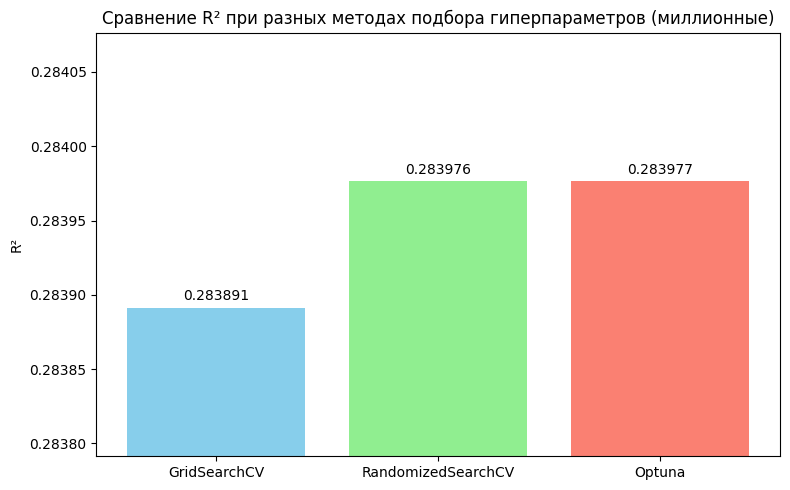

In [384]:
models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores, color=[
              'skyblue', 'lightgreen', 'salmon'])

ax.set_ylabel('R²')
ax.set_title(
    'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

margin = 0.0001
y_min = min(r2_scores) - margin
y_max = max(r2_scores) + margin

ax.set_ylim(y_min, y_max)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.6f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Обучение с наилучшим гиперпараметром

In [385]:
ridge_best = Ridge(alpha=0.0001).fit(X_train, y_train)
y_pred_new = ridge_best.predict(X_test)

### Метрики с наилучшим гиперпараметром

In [386]:
sklearn_metrick_printer(y_test, y_pred_new)

MAE: 0.568052543296296
MSE: 0.5365319461485085
RMSE: 0.7324834101524133
MAPE: 0.10199485096824919
R^2: 0.2989899387379119


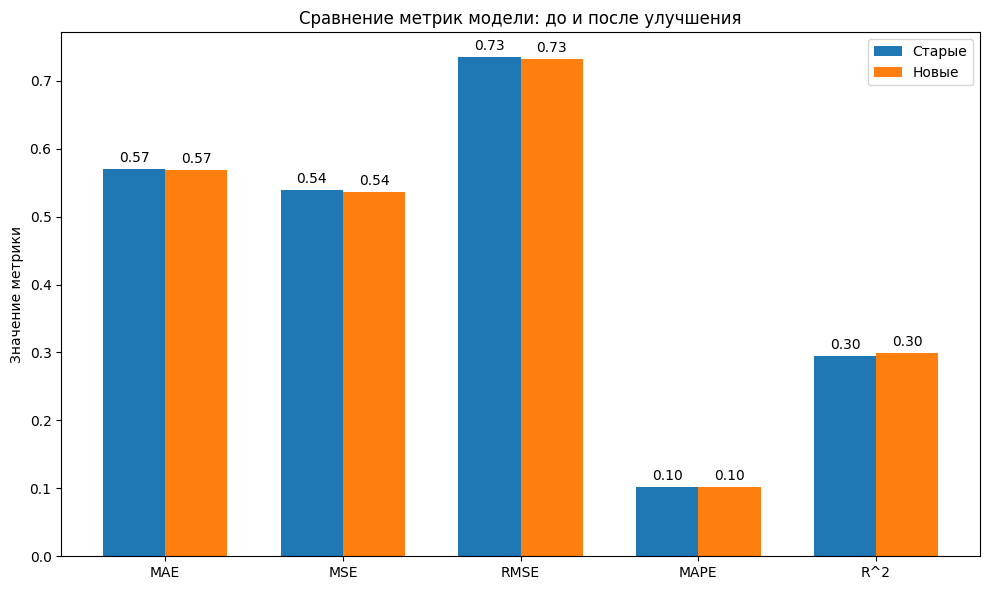

In [387]:
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R^2']

old_values = return_metricks(y_test, y_pred)

new_values = return_metricks(y_test, y_pred_new)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Старые')
bars2 = ax.bar(x + width/2, new_values, width, label='Новые')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик модели: до и после улучшения')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_16176\2118410706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\andre\AppData\Local\Temp\ipykernel_16176\2118410706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns

<Axes: xlabel='quality', ylabel='Density'>

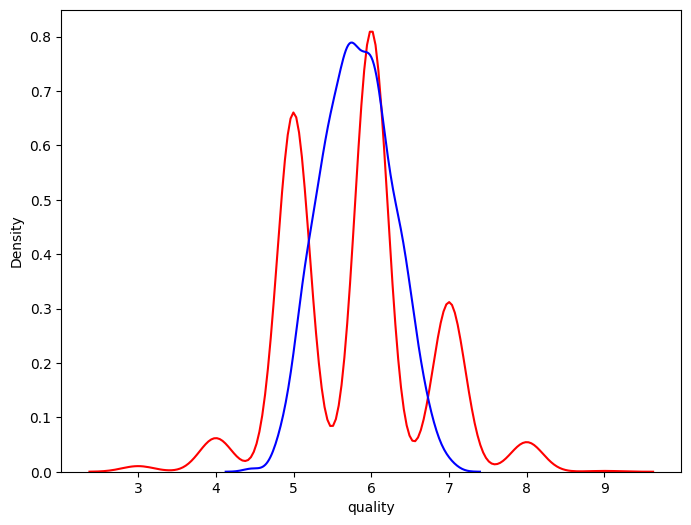

In [388]:
plt.figure(figsize=(8, 6))

ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred_new, hist=False, color='Blue',
             ax=ax1, label='Predicted weight')

## Линейная регрессия с двумя регуляризаторами

In [389]:
base_elastic_model = ElasticNet(max_iter=100000, alpha=1.0, l1_ratio=0.5)
base_elastic_model.fit(X_train, y_train)
y_pred = base_elastic_model.predict(X_test)

### Метрики

In [390]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.6813702166229092
MSE: 0.7567632469325437
RMSE: 0.8699214027327663
MAPE: 0.12312358782596343
R^2: 0.011244989415335582


In [391]:
metrick_printer(y_test, y_pred)

MAE: 0.6813702166229092
MSE: 0.7567632469325437
RMSE: 0.8699214027327663
MAPE: 0.12312358782596343
R^2: 0.0007605807773728187


In [392]:
len(base_elastic_model.coef_)
base_elastic_model.coef_

array([-0.        , -0.        ,  0.        , -0.        , -0.        ,
        0.00495125, -0.00159803, -0.        ,  0.        ,  0.        ,
        0.        ])

### Подбор гиперпараметров

GridSearchCV

In [393]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

In [394]:
grid = GridSearchCV(
    ElasticNet(max_iter=100000),
    param_grid,
    scoring='r2',
    cv=5
)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=ElasticNet(max_iter=100000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10],
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
             scoring='r2')

In [395]:
print("Best params:", grid.best_params_)
print("Best R^2:", grid.best_score_)

Best params: {'alpha': 0.001, 'l1_ratio': 0.1}
Best R^2: 0.2823658412406741


RandomizedSearchCV

In [396]:
param_dist = {
    'alpha': np.logspace(-4, 1, 100),
    'l1_ratio': np.linspace(0.1, 0.9, 9)
}

In [397]:
random_search = RandomizedSearchCV(
    ElasticNet(max_iter=100000),
    param_distributions=param_dist,
    n_iter=30,
    scoring='r2',
    cv=5,
    random_state=42
)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=ElasticNet(max_iter=100000), n_iter=30,
                   param_distributions={'alpha': array([1.00000000e-04, 1.12332403e-04, 1.26185688e-04, 1.41747416e-04,
       1.59228279e-04, 1.78864953e-04, 2.00923300e-04, 2.25701972e-04,
       2.53536449e-04, 2.84803587e-04, 3.19926714e-04, 3.59381366e-04,
       4.03701726e-04, 4.53487851e-04, 5.09413801e-04, 5.72236766e-04,
       6....
       1.09749877e+00, 1.23284674e+00, 1.38488637e+00, 1.55567614e+00,
       1.74752840e+00, 1.96304065e+00, 2.20513074e+00, 2.47707636e+00,
       2.78255940e+00, 3.12571585e+00, 3.51119173e+00, 3.94420606e+00,
       4.43062146e+00, 4.97702356e+00, 5.59081018e+00, 6.28029144e+00,
       7.05480231e+00, 7.92482898e+00, 8.90215085e+00, 1.00000000e+01]),
                                        'l1_ratio': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])},
                   random_state=42, scoring='r2')

In [398]:
print("Best params:", random_search.best_params_)
print("Best R^2:", random_search.best_score_)

Best params: {'l1_ratio': np.float64(0.8), 'alpha': np.float64(0.0002257019719633919)}
Best R^2: 0.28264755650367024


Фреймворк Optuna

In [399]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
    l1_ratio = trial.suggest_uniform('l1_ratio', 0.1, 0.9)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=100000)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()
    return score

In [400]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

[I 2025-06-01 20:24:59,092] A new study created in memory with name: no-name-125f387e-bf5e-4585-b558-3b830e0478a4
C:\Users\andre\AppData\Local\Temp\ipykernel_16176\4049124632.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
C:\Users\andre\AppData\Local\Temp\ipykernel_16176\4049124632.py:3: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  l1_ratio = trial.suggest_uniform('l1_ratio', 0.1, 0.9)
[I 2025-06-01 20:24:59,108] Trial 0 finished with value: -0.0004899337765517763 and parameters: {'alpha': 3.4295551876605956, 'l1_ratio': 0.8090059264730302}. Best is trial 0 with value: -0.0004899337765517763.
C:\Users\andre\AppData\Local\Temp\ip

In [401]:
print("Best params:", study.best_params)
print("Best R^2:", study.best_value)

Best params: {'alpha': 0.0001025198891083713, 'l1_ratio': 0.7273871969369397}
Best R^2: 0.2826508221221046


Сравнение гиперпараметров

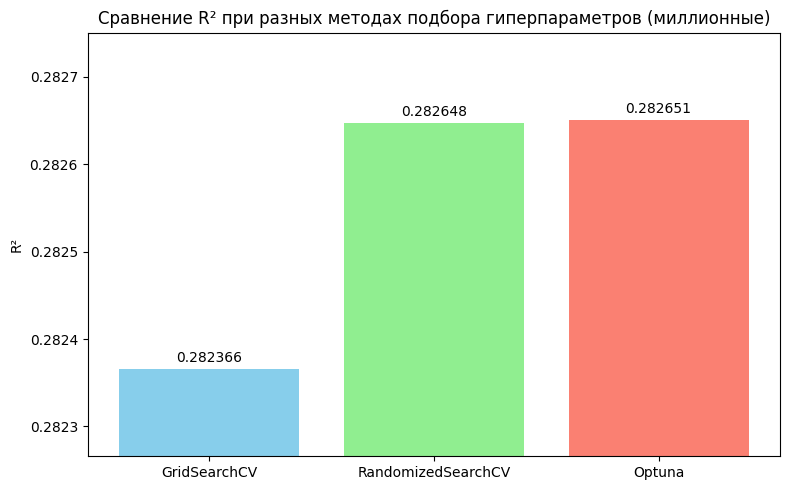

In [402]:
models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores, color=[
              'skyblue', 'lightgreen', 'salmon'])

ax.set_ylabel('R²')
ax.set_title(
    'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

margin = 0.0001
y_min = min(r2_scores) - margin
y_max = max(r2_scores) + margin

ax.set_ylim(y_min, y_max)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.6f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Обучение с наилучшим гиперпараметром

In [403]:
base_elastic_model = ElasticNet(max_iter=100000, alpha=0.000253, l1_ratio=0.1)
base_elastic_model.fit(X_train, y_train)
y_pred_new = base_elastic_model.predict(X_test)

### Метрики с наилучшим гиперпараметром

In [404]:
sklearn_metrick_printer(y_test, y_pred_new)

MAE: 0.5705357386349454
MSE: 0.5397182518864788
RMSE: 0.7346551925131128
MAPE: 0.10239081267216368
R^2: 0.2948268457541513


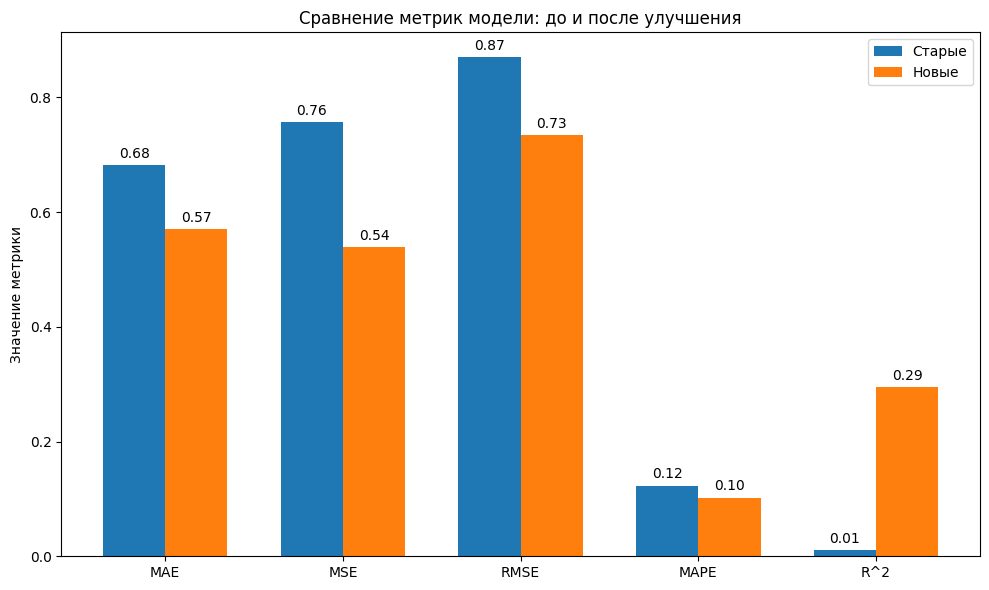

In [405]:
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R^2']

old_values = return_metricks(y_test, y_pred)

new_values = return_metricks(y_test, y_pred_new)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Старые')
bars2 = ax.bar(x + width/2, new_values, width, label='Новые')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик модели: до и после улучшения')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_16176\2118410706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\andre\AppData\Local\Temp\ipykernel_16176\2118410706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns

<Axes: xlabel='quality', ylabel='Density'>

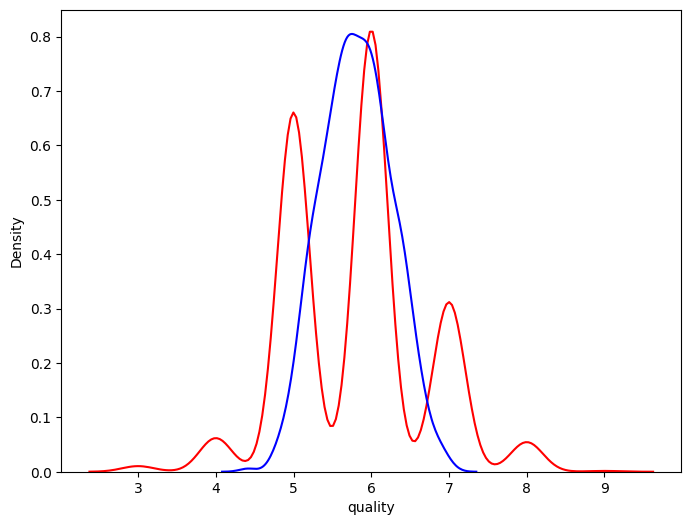

In [406]:
plt.figure(figsize=(8, 6))

ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred_new, hist=False, color='Blue',
             ax=ax1, label='Predicted weight')

## Полиномиальная регрессия

In [434]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [435]:
polynomial_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

In [436]:
polynomial_model.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()), ('reg', LinearRegression())])

In [437]:
y_pred = polynomial_model.predict(X_test)

### Метрики

In [439]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5582497659833561
MSE: 0.508566523583546
RMSE: 0.7131385023847373
MAPE: 0.10012132185262089
R^2: 0.33552838295584164


In [412]:
metrick_printer(y_test, y_pred)

MAE: 0.5582497659833561
MSE: 0.508566523583546
RMSE: 0.7131385023847373
MAPE: 0.10012132185262089
R^2: 0.000511132013110891


In [413]:
polynomial_model.named_steps['reg'].coef_

array([-4.35449777e+01, -2.44797062e+01,  5.36302834e+01, -9.21018135e+01,
       -4.21654853e+01,  1.01789784e+01,  8.49451818e+01,  3.16866218e+01,
        4.38471354e+01, -1.36197574e+01,  4.42664534e+01, -9.02686275e-01,
       -8.90044492e-02,  6.12535321e-01, -6.83993033e-01, -7.34885975e-01,
       -3.84740055e-02,  3.06959379e-01,  4.38233095e+01,  5.45712227e-01,
        2.24475603e-02,  5.88067879e-01,  4.99028692e-02,  4.66849961e-02,
       -2.60028775e-01,  1.54306837e-01, -2.50434962e-02,  1.19043072e-01,
        2.33810272e+01,  3.61884513e-02, -4.94622786e-03,  8.94651176e-01,
       -1.26840012e-01,  2.10556391e-01,  7.10225211e-02,  1.10691133e-01,
        7.81740009e-03, -5.49648575e+01,  9.74504997e-01, -3.28462860e-02,
       -2.98779669e-01, -9.36931843e-01, -2.66287686e-01, -6.44562332e-02,
        6.91555244e-01,  9.37678360e+01, -7.59061431e-01, -2.50568688e-01,
        1.18306226e+00, -4.34089216e-02,  2.15514310e-02, -5.57151953e-02,
        4.45871299e+01, -

### Подбор гиперпараметров

GridSearchCV

In [420]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', ElasticNet(max_iter=100000))
])

In [421]:
param_grid = {
    'poly__degree': [2, 3],
    'reg__alpha': [0.001, 0.01, 0.1, 1],
    'reg__l1_ratio': [0.2, 0.5, 0.8]
}

In [422]:
grid = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, scoring='r2')
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('reg', ElasticNet(max_iter=100000))]),
             n_jobs=-1,
             param_grid={'poly__degree': [2, 3],
                         'reg__alpha': [0.001, 0.01, 0.1, 1],
                         'reg__l1_ratio': [0.2, 0.5, 0.8]},
             scoring='r2')

In [423]:
print("Best params:", grid.best_params_)
print("Best R^2:", grid.best_score_)

Best params: {'poly__degree': 3, 'reg__alpha': 0.001, 'reg__l1_ratio': 0.8}
Best R^2: 0.3238222796020878


RandomizedSearchCV

In [424]:
param_dist = {
    'poly__degree': [2, 3],
    'reg__alpha': np.logspace(-4, 1, 100),
    'reg__l1_ratio': np.linspace(0.1, 0.9, 9)
}

In [425]:
random_search = RandomizedSearchCV(
    pipeline, param_distributions=param_dist,
    n_iter=30, cv=5, n_jobs=-1, scoring='r2', random_state=42
)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('poly',
                                              PolynomialFeatures(include_bias=False)),
                                             ('scaler', StandardScaler()),
                                             ('reg',
                                              ElasticNet(max_iter=100000))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'poly__degree': [2, 3],
                                        'reg__alpha': array([1.00000000e-04, 1.12332403e-04, 1.26185688e-04, 1.41747416e-04,
       1.59228279e-04, 1.78864953e-04, 2.00923300e-04...
       1.09749877e+00, 1.23284674e+00, 1.38488637e+00, 1.55567614e+00,
       1.74752840e+00, 1.96304065e+00, 2.20513074e+00, 2.47707636e+00,
       2.78255940e+00, 3.12571585e+00, 3.51119173e+00, 3.94420606e+00,
       4.43062146e+00, 4.97702356e+00, 5.59081018e+00, 6.28029144e+00,
       7.05480231e+00, 7.92482898e+00, 8.90215085e+00, 1.00000000e+01]),
                                        'reg__l1_ratio': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])},
                   random_state=42, scoring='r2')

In [429]:
print("Best params:", random_search.best_params_)
print("Best R^2:", random_search.best_score_)

Best params: {'reg__l1_ratio': np.float64(0.1), 'reg__alpha': np.float64(0.05994842503189409), 'poly__degree': 2}
Best R^2: 0.30250543071904634


Фреймворк Optuna

In [426]:
def objective(trial):
    degree = trial.suggest_int('degree', 2, 3)
    alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
    l1_ratio = trial.suggest_uniform('l1_ratio', 0.1, 0.9)

    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg', ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=100000))
    ])

    score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2').mean()
    return score

In [427]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40, n_jobs=-1)

[I 2025-06-01 20:57:46,953] A new study created in memory with name: no-name-0c50a1c2-e096-414f-9f12-f4f54dc9ce99
C:\Users\andre\AppData\Local\Temp\ipykernel_16176\2030623893.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
C:\Users\andre\AppData\Local\Temp\ipykernel_16176\2030623893.py:4: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  l1_ratio = trial.suggest_uniform('l1_ratio', 0.1, 0.9)
C:\Users\andre\AppData\Local\Temp\ipykernel_16176\2030623893.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float

In [428]:
print("Best params:", study.best_params)
print("Best R^2:", study.best_value)

Best params: {'degree': 2, 'alpha': 0.021383265684033776, 'l1_ratio': 0.10140699712655875}
Best R^2: 0.306007602757613


Сравнение гиперпараметров

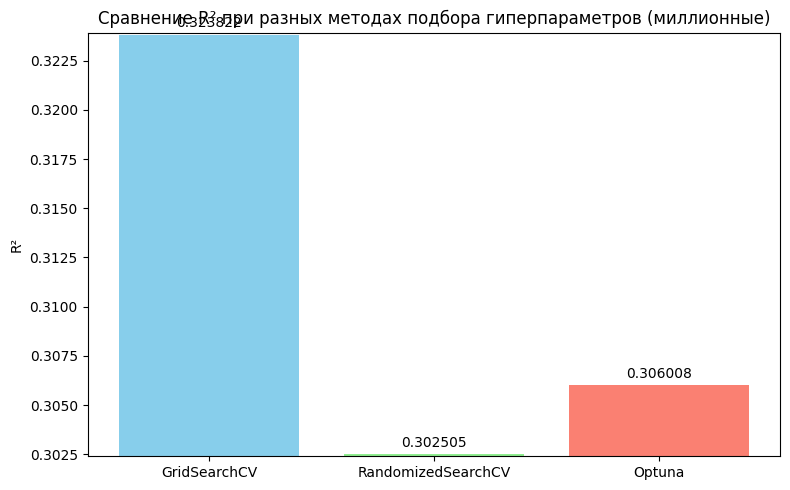

In [430]:
models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores, color=[
              'skyblue', 'lightgreen', 'salmon'])

ax.set_ylabel('R²')
ax.set_title(
    'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

margin = 0.0001
y_min = min(r2_scores) - margin
y_max = max(r2_scores) + margin

ax.set_ylim(y_min, y_max)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.6f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Обучение с наилучшим гиперпараметром

In [440]:
polynomial_model_best = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

polynomial_model_best.fit(X_train, y_train)
y_pred_new = polynomial_model_best.predict(X_test)

### Метрики с наилучшим гиперпараметром

In [441]:
sklearn_metrick_printer(y_test, y_pred_new)

MAE: 0.5582497659833561
MSE: 0.508566523583546
RMSE: 0.7131385023847373
MAPE: 0.10012132185262089
R^2: 0.33552838295584164


In [99]:
polynomial_model_best.named_steps['reg'].coef_

array([-2.97030541e+01, -1.32116434e+01,  5.60513157e+01, -9.01372983e+01,
       -6.20560131e+01,  1.41791776e+01,  8.08320389e+01,  2.00487400e+00,
        5.92248891e+01, -1.15675587e+00,  2.26614064e+01, -9.96495596e-01,
        6.72630242e-02,  7.36289145e-01, -7.66035107e-01, -9.10996247e-01,
        3.26790054e-01,  1.22278431e-02,  2.99840123e+01,  7.06713114e-01,
        2.37752867e-01,  2.16917054e-01,  4.52734500e-02, -1.46353280e-02,
       -1.98514976e-01,  8.79444461e-02, -1.67733168e-02,  1.15483238e-01,
        1.19081672e+01,  2.49617692e-01, -1.09856396e-02,  7.93492005e-01,
       -1.23686973e-01,  2.83202672e-01,  1.38044973e-01,  9.36386781e-02,
       -4.52649978e-03, -5.77838038e+01,  1.13352431e+00,  2.35147446e-02,
       -2.04362040e-01, -8.37550092e-01, -2.77174205e-01, -3.85535353e-02,
        6.22596484e-01,  9.12365886e+01, -1.45930159e-01, -1.43227851e-01,
        1.00707853e+00, -9.46794720e-02, -5.77754563e-03, -4.28734596e-02,
        6.50754661e+01, -

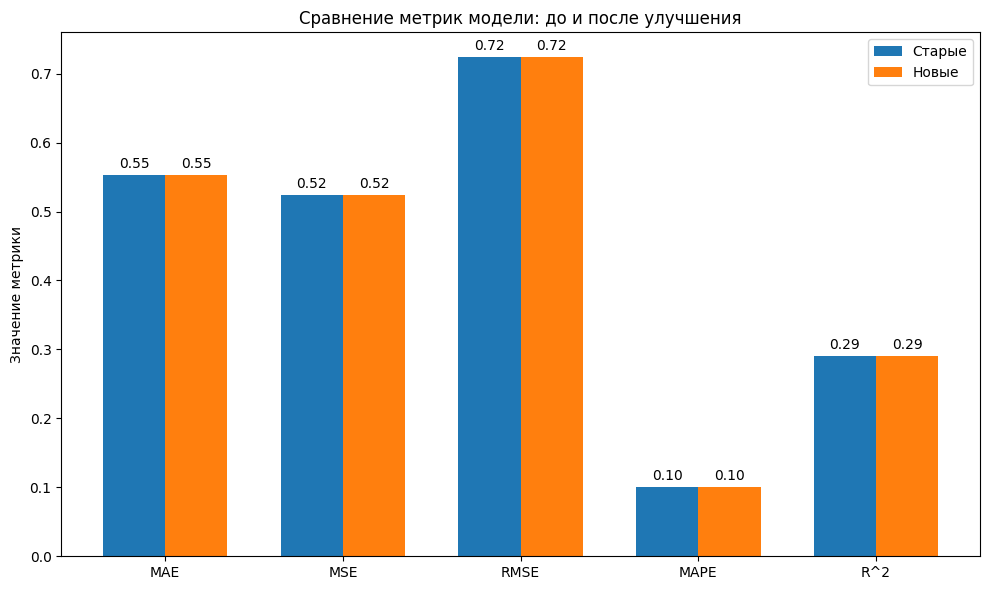

In [100]:
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R^2']

old_values = return_metricks(y_test, y_pred)

new_values = return_metricks(y_test, y_pred_new)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Старые')
bars2 = ax.bar(x + width/2, new_values, width, label='Новые')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик модели: до и после улучшения')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_18468\2118410706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\andre\AppData\Local\Temp\ipykernel_18468\2118410706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns

<Axes: xlabel='quality', ylabel='Density'>

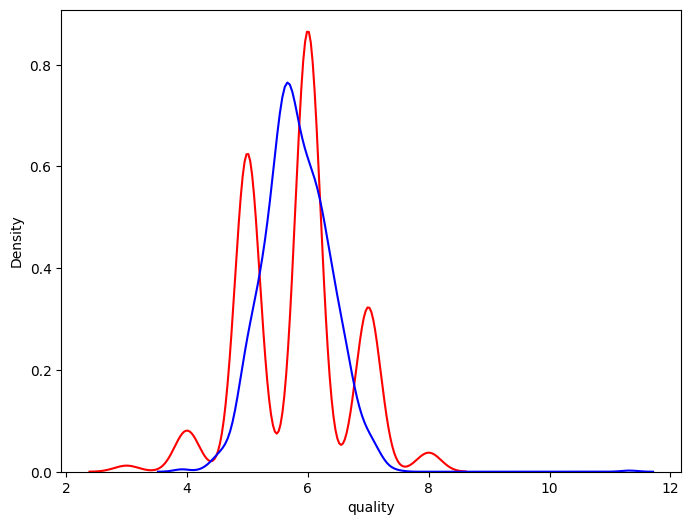

In [101]:
plt.figure(figsize=(8, 6))

ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred_new, hist=False, color='Blue',
             ax=ax1, label='Predicted weight')

## Влияние предикторов на целевой признак

In [1]:
features = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar", "chlorides",
    "free_sulfur_dioxide", "total_sulfur_dioxide", "density", "pH", "sulphates", "alcohol"
]
weights = np.array([
    0.01527086, -1.47784147, -0.06488792, 0.02390045, -0.70087447,
    0.00559915, -0.0024541, -0.0, 0.15563081, 0.6031466, 0.33379409
])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(features, weights, color=np.where(weights >= 0, 'green', 'red'))

ax.set_title("Влияние признаков на оценку вина")
ax.set_ylabel("Вес призанка")
ax.axhline(0, color='gray', linewidth=0.8)

plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -12), textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

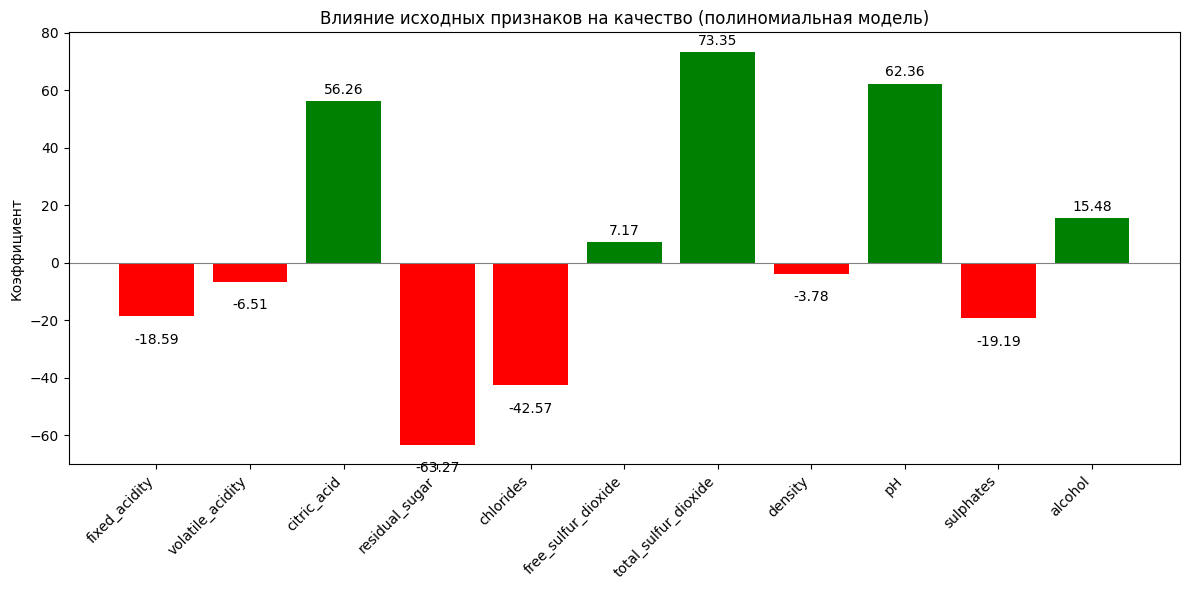

In [416]:
features = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar", "chlorides",
    "free_sulfur_dioxide", "total_sulfur_dioxide", "density", "pH", "sulphates", "alcohol"
]

n_features = len(features)

weights = np.array([-1.85872610e+01, -6.51061878e+00,  5.62617044e+01, -6.32742470e+01,
                    -4.25687169e+01,  7.17180908e+00,  7.33523247e+01, -3.78215024e+00,
                    6.23627112e+01, -1.91919956e+01,  1.54754279e+01, -7.40129989e-01,
                    3.85048246e-02,  7.74992453e-01, -4.67938896e-01, -5.82172570e-01,
                    1.68269680e-01,  7.44640829e-02,  1.81843802e+01,  1.27140205e+00,
                    3.28226767e-02, -1.07474030e-01,  4.95819450e-02,  3.09516850e-02,
                    -1.97433735e-01,  1.10833480e-01,  1.88947061e-03,  5.67360951e-02,
                    5.48993192e+00,  1.95469226e-01,  1.03050303e-02,  5.32963886e-01,
                    -1.27165738e-01,  2.37190568e-01,  1.35444306e-01,  1.05202074e-01,
                    9.96699254e-03, -5.78948058e+01,  1.16495859e+00, -7.63901658e-02,
                    -3.18351188e-01, -7.54121380e-01, -2.37121931e-01, -9.68459198e-02,
                    5.31126317e-01,  6.42458308e+01,  3.81053402e-02, -2.64698873e-01,
                    6.63358285e-01, -5.85874377e-02,  2.47083690e-02, -6.87006994e-02,
                    4.46325966e+01, -1.28320182e+00, -3.35305011e-01,  5.16687941e-02,
                    -1.18724818e-01, -1.11721136e-01, -8.08216883e+00,  3.99518250e-01,
                    1.58005614e-01,  3.89950552e-01,  2.92729018e-02, -7.32942521e+01,
                    7.86282178e-01, -3.34179228e-01, -9.96907233e-01,  7.60905378e+00,
                    -6.35093872e+01,  1.92856132e+01, -1.36851041e+01,  1.12485841e+00,
                    2.24706535e-01, -1.62166323e+00, -9.69779600e-02,  2.57193339e-01,
                    9.49497170e-02])

original_weights = weights[:n_features]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(features, original_weights, color=np.where(
    original_weights >= 0, 'green', 'red'))

ax.set_title("Влияние исходных признаков на качество (полиномиальная модель)")
ax.set_ylabel("Коэффициент")
ax.axhline(0, color='gray', linewidth=0.8)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -12), textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.show()

## Линейный регрессор

In [24]:
import numpy as np

from sklearn.preprocessing import StandardScaler

In [ ]:
import numpy as np


class RegressioDICH:
    def __init__(self, alpha=0.1, lr=0.01, n_iter=5000):
        self.alpha = alpha
        self.lr = lr
        self.n_iter = n_iter

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(1, self.n_iter + 1):
            y_pred = X.dot(self.weights) + self.bias

            dw = (1 / n_samples) * (X.T.dot(y_pred - y)) + \
                self.alpha * self.weights
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return X.dot(self.weights) + self.bias

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = RegressioDICH(alpha=0.1, lr=0.001, n_iter=5000, verbose=True)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5677582000810317
MSE: 0.5451308678012033
RMSE: 0.7383297825505912
MAPE: 0.1004819085109859
R^2: 0.26188711672368437
